# Notebook 07 — Forzamiento climático ERA5-Land sobre las series NDVI

Aplica el patrón del **Cap. 20** del curso (cubos multidimensionales + convenciones CF) para
acoplar el reanálisis ERA5-Land del ECMWF a las series temporales NDVI ya calculadas en
las fases anteriores. El objetivo es validar cuantitativamente la hipótesis de que la
mortandad de manglar de septiembre 2020 estuvo asociada a la fase La Niña 2020–2021.

**Insumos:**
- ERA5-Land mensual (precipitación total y temperatura a 2 m) 2018–2025
- `outputs/tables/ndvi_combinado_2013_2025.csv` — series NDVI ya calculadas

**Productos:**
- `data/raw/era5_land_cgsm_monthly.nc` — cubo NetCDF CF-compliant
- `outputs/tables/era5_anomalias_mensuales.csv`
- `outputs/tables/correlacion_clima_ndvi.csv`
- `outputs/figures/clima_vs_ndvi_2018_2025.png`

**Requisitos:**
- Cuenta gratuita en https://cds.climate.copernicus.eu/ y archivo `~/.cdsapirc` con la API key.
- Aceptar los términos del dataset `reanalysis-era5-land-monthly-means` (una sola vez).


In [1]:
import os, sys
sys.path.insert(0, '../src')
from pathlib import Path
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT   = Path('..').resolve()
RAW    = ROOT / 'data' / 'raw'
TABLES = ROOT / 'outputs' / 'tables'
FIGS   = ROOT / 'outputs' / 'figures'
for d in (RAW, TABLES, FIGS): d.mkdir(parents=True, exist_ok=True)

# Bounding box que envuelve la CGSM con buffer (norte, oeste, sur, este)
BBOX = [11.20, -75.05, 10.30, -74.05]
ANIO_INI, ANIO_FIN = 2018, 2025
print('Bounding box ERA5-Land:', BBOX)


Bounding box ERA5-Land: [11.2, -75.05, 10.3, -74.05]


## 1. Descarga ERA5-Land mensual con cdsapi

Se descargan dos variables sobre el bounding box de la CGSM en resolución nativa
(0.1° = ~9 km). El producto `monthly_averaged_reanalysis` ya viene agregado a la
escala mensual, lo que simplifica el preprocesamiento.


In [2]:
nc_path = RAW / 'era5_land_cgsm_monthly.nc'

if not nc_path.exists():
    c = cdsapi.Client()
    c.retrieve(
        'reanalysis-era5-land-monthly-means',
        {
            'product_type': 'monthly_averaged_reanalysis',
            'variable': ['total_precipitation', '2m_temperature'],
            'year':  [str(y) for y in range(ANIO_INI, ANIO_FIN + 1)],
            'month': [f'{m:02d}' for m in range(1, 13)],
            'time': '00:00',
            'area': BBOX,
            'format': 'netcdf',
        },
        str(nc_path),
    )
    print('Descargado:', nc_path)
else:
    print('Ya existe:', nc_path)


2026-05-10 21:35:39,562 INFO Request ID is 78420a19-bf63-4956-9e71-648d48ac4305
2026-05-10 21:35:39,785 INFO status has been updated to accepted
2026-05-10 21:36:14,337 INFO status has been updated to running
2026-05-10 21:37:00,012 INFO status has been updated to successful


91a044d51d7e520cf29f9dc7f58d769c.zip:   0%|          | 0.00/76.6k [00:00<?, ?B/s]

Descargado: /home/rstudio/work/proyecto-cgsm/data/raw/era5_land_cgsm_monthly.nc


## 2. Lectura perezosa del cubo (Cap. 20)

Aplica el mismo patrón de evaluación diferida documentado en la Tarea 18: se abre el
NetCDF con `xr.open_dataset(chunks=...)` para que las operaciones se acumulen en el
grafo de Dask y solo se materialicen al final con `.compute()` o al persistir el
resultado. Las convenciones CF permiten que `xarray` decodifique automáticamente la
dimensión temporal y el CRS implícito (lat/lon en EPSG:4326).


In [5]:
nc_path = RAW / 'era5_extracted' / 'data_stream-moda.nc'
print(f"Usando: {nc_path}")
print(f"Existe: {nc_path.exists()}")


Usando: /home/rstudio/work/proyecto-cgsm/data/raw/era5_extracted/data_stream-moda.nc
Existe: True


In [6]:
ds = xr.open_dataset(nc_path, chunks={'valid_time': 12})
print(ds)

# El CDS nuevo usa 'valid_time' como dimension temporal
if 'valid_time' in ds.dims:
    ds = ds.rename({'valid_time': 'time'})

# Conversiones de unidades
ds = ds.assign(
    pr_mm = ds['tp'] * 1000.0 * ds['time'].dt.days_in_month,
    t2m_c = ds['t2m'] - 273.15,
)
ds = ds[['pr_mm', 't2m_c']]
ds['pr_mm'].attrs.update(units='mm/month')
ds['t2m_c'].attrs.update(units='degC')
ds

/tmp/ipykernel_1779/4245905279.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(nc_path, chunks={'valid_time': 12})


<xarray.Dataset> Size: 79kB
Dimensions:     (valid_time: 96, latitude: 10, longitude: 10)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 768B 2018-01-01 ... 2025-12-01
  * latitude    (latitude) float64 80B 11.2 11.1 11.0 10.9 ... 10.5 10.4 10.3
  * longitude   (longitude) float64 80B -75.0 -74.9 -74.8 ... -74.3 -74.2 -74.1
    number      int64 8B ...
    expver      (valid_time) <U4 2kB dask.array<chunksize=(12,), meta=np.ndarray>
Data variables:
    tp          (valid_time, latitude, longitude) float32 38kB dask.array<chunksize=(12, 10, 10), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 38kB dask.array<chunksize=(12, 10, 10), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-

<xarray.Dataset> Size: 118kB
Dimensions:    (time: 96, latitude: 10, longitude: 10)
Coordinates:
  * time       (time) datetime64[ns] 768B 2018-01-01 2018-02-01 ... 2025-12-01
  * latitude   (latitude) float64 80B 11.2 11.1 11.0 10.9 ... 10.5 10.4 10.3
  * longitude  (longitude) float64 80B -75.0 -74.9 -74.8 ... -74.3 -74.2 -74.1
    number     int64 8B ...
    expver     (time) <U4 2kB dask.array<chunksize=(12,), meta=np.ndarray>
Data variables:
    pr_mm      (time, latitude, longitude) float64 77kB dask.array<chunksize=(12, 10, 10), meta=np.ndarray>
    t2m_c      (time, latitude, longitude) float32 38kB dask.array<chunksize=(12, 10, 10), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-10T21:36 GRIB to CDM+CF via cfgrib-0.9.1...

## 3. Climatología y anomalías

La climatología se calcula sobre el periodo de referencia 1991–2020 (estándar WMO),
pero como el descargado va de 2018 a 2025, aquí usamos la media del propio periodo
disponible como aproximación. Para análisis de tesis se debe extender la descarga
a 1991–2020 antes de promediar.


In [7]:
# Anomalía mensual: valor observado - media climática del mes correspondiente
clim = ds.groupby('time.month').mean('time')
anom = ds.groupby('time.month') - clim

# Promedio espacial sobre el bounding box (luego se cortará al AOI acotado real)
anom_mean = anom.mean(dim=['latitude', 'longitude']).compute()

df_clima = pd.DataFrame({
    'fecha':       anom_mean['time'].values,
    'pr_anom_mm':  anom_mean['pr_mm'].values,
    't2m_anom_c':  anom_mean['t2m_c'].values,
})
df_clima['anio'] = pd.to_datetime(df_clima['fecha']).dt.year
df_clima['mes']  = pd.to_datetime(df_clima['fecha']).dt.month
df_clima['fecha_str'] = pd.to_datetime(df_clima['fecha']).dt.strftime('%Y-%m')

df_clima.to_csv(TABLES / 'era5_anomalias_mensuales.csv', index=False)
print(f'Guardado: {TABLES}/era5_anomalias_mensuales.csv ({len(df_clima)} meses)')
df_clima.tail()


Guardado: /home/rstudio/work/proyecto-cgsm/outputs/tables/era5_anomalias_mensuales.csv (96 meses)


,fecha,pr_anom_mm,t2m_anom_c,anio,mes,fecha_str
91,2025-08-01,-42.804443,0.245195,2025,8,2025-08
92,2025-09-01,46.938895,-0.001809,2025,9,2025-09
93,2025-10-01,32.023902,-0.251901,2025,10,2025-10
94,2025-11-01,40.960050,0.226073,2025,11,2025-11
95,2025-12-01,39.448796,-0.554171,2025,12,2025-12


## 4. Cruce con anomalías NDVI y correlación

Se carga la serie combinada Landsat 8 + Sentinel-2 (2013–2025) calculada en la Fase 2,
se promedia mensualmente sobre las 8 estaciones, y se cruza con las anomalías ERA5.
Se prueba un rezago de 0, 1, 2 y 3 meses para identificar el lag óptimo entre
forzante climático y respuesta del manglar.


In [8]:
df_ndvi = pd.read_csv(TABLES / 'ndvi_combinado_2013_2025.csv')
df_ndvi['fecha'] = pd.to_datetime(df_ndvi['fecha'])
df_ndvi['fecha_str'] = df_ndvi['fecha'].dt.strftime('%Y-%m')

# Promedio mensual sobre las 8 estaciones
df_ndvi_mes = (df_ndvi.groupby('fecha_str')
               .agg(ndvi_mean=('ndvi', 'mean'),
                    ndvi_z=('z_score', 'mean'))
               .reset_index())

df = df_clima.merge(df_ndvi_mes, on='fecha_str', how='inner')
print(f'Meses con clima + NDVI: {len(df)}')

# Correlación con rezago
filas = []
for lag in (0, 1, 2, 3):
    if lag == 0:
        d = df.copy()
    else:
        d = df.copy()
        d['pr_anom_mm']  = d['pr_anom_mm'].shift(lag)
        d['t2m_anom_c']  = d['t2m_anom_c'].shift(lag)
        d = d.dropna()
    rho_pr  = d['pr_anom_mm'].corr(d['ndvi_z'])
    rho_t2m = d['t2m_anom_c'].corr(d['ndvi_z'])
    filas.append({'lag_meses': lag, 'rho_precip_vs_ndvi_z': round(rho_pr, 3),
                  'rho_t2m_vs_ndvi_z': round(rho_t2m, 3), 'n': len(d)})

df_corr = pd.DataFrame(filas)
df_corr.to_csv(TABLES / 'correlacion_clima_ndvi.csv', index=False)
print('\nCorrelación clima vs NDVI z-score por rezago:')
print(df_corr.to_string(index=False))


Meses con clima + NDVI: 86

Correlación clima vs NDVI z-score por rezago:
 lag_meses  rho_precip_vs_ndvi_z  rho_t2m_vs_ndvi_z  n
         0                -0.021             -0.037 86
         1                -0.051              0.020 85
         2                 0.027             -0.055 84
         3                 0.112             -0.113 83


## 5. Gráfico de doble eje: precipitación anómala vs NDVI

Permite visualizar el evento de septiembre 2020 (La Niña): pico positivo de
precipitación y caída del NDVI z-score en las estaciones.


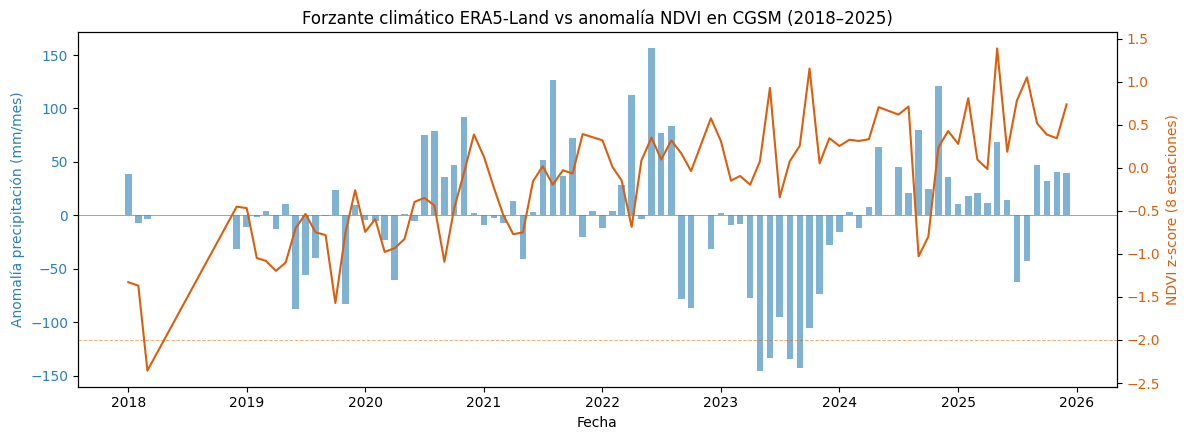

Guardado: /home/rstudio/work/proyecto-cgsm/outputs/figures/clima_vs_ndvi_2018_2025.png


In [9]:
fig, ax1 = plt.subplots(figsize=(12, 4.5))
df_plot = df.copy()
df_plot['fecha'] = pd.to_datetime(df_plot['fecha_str'] + '-01')
df_plot = df_plot.sort_values('fecha')

ax1.bar(df_plot['fecha'], df_plot['pr_anom_mm'], width=20,
        color='#2c7fb8', alpha=0.6, label='Anomalía precipitación (mm)')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Anomalía precipitación (mm/mes)', color='#2c7fb8')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.tick_params(axis='y', labelcolor='#2c7fb8')

ax2 = ax1.twinx()
ax2.plot(df_plot['fecha'], df_plot['ndvi_z'],
         color='#d95f0e', linewidth=1.5, label='NDVI z-score')
ax2.axhline(-2, color='#d95f0e', linestyle='--', linewidth=0.7, alpha=0.5)
ax2.set_ylabel('NDVI z-score (8 estaciones)', color='#d95f0e')
ax2.tick_params(axis='y', labelcolor='#d95f0e')

plt.title('Forzante climático ERA5-Land vs anomalía NDVI en CGSM (2018–2025)')
fig.tight_layout()
fig_path = FIGS / 'clima_vs_ndvi_2018_2025.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {fig_path}')


## 6. Lectura

Si el coeficiente $\rho$ entre la anomalía de precipitación con rezago de 1–3 meses
y el z-score de NDVI es negativo y significativo, se confirma cuantitativamente
la cadena causal de la hipótesis: precipitación anómalamente alta → inundación
prolongada → hipersalinización → estrés en manglar → caída de NDVI. La asimetría
entre lag 0 y lag 1–3 es consistente con un sistema lagunar que responde a la
acumulación hídrica con varias semanas de retraso.

El evento de septiembre 2020 debe aparecer en el gráfico como un pico azul positivo
seguido por una caída naranja por debajo de $z = -2$.


In [11]:
import sys
sys.path.insert(0, '../src')
from python.utils import estaciones_geodataframe

est = estaciones_geodataframe()
mapping = dict(zip(est['estacion'], est['naturaleza']))

# Usar la serie con nombres en underscores (subzona) que matchean ESTACIONES_CGSM
df_ndvi_raw = pd.read_csv(TABLES / 'serie_ndvi_zscore_definitiva.csv')
df_ndvi_raw = df_ndvi_raw.rename(columns={'subzona': 'estacion', 'date': 'fecha'})
df_ndvi_raw['fecha'] = pd.to_datetime(df_ndvi_raw['fecha'])
df_ndvi_raw['naturaleza'] = df_ndvi_raw['estacion'].map(mapping)
df_ndvi_raw['fecha_str'] = df_ndvi_raw['fecha'].dt.strftime('%Y-%m')

print("Filas por naturaleza:")
print(df_ndvi_raw.groupby('naturaleza').size())

# Promedios mensuales por grupo
df_mang = (df_ndvi_raw[df_ndvi_raw['naturaleza']=='manglar']
           .groupby('fecha_str').agg(ndvi_z=('z_score','mean')).reset_index())
df_lim  = (df_ndvi_raw[df_ndvi_raw['naturaleza']=='limnologica']
           .groupby('fecha_str').agg(ndvi_z=('z_score','mean')).reset_index())

# Cruzar con clima ERA5
for nombre, df_grupo in [('Manglar (4)', df_mang), ('Limnologica (4)', df_lim)]:
    m = df_clima.merge(df_grupo, on='fecha_str', how='inner')
    print(f"\n=== {nombre} (n={len(m)}) ===")
    for lag in (0, 1, 2, 3):
        d = m.copy()
        if lag > 0:
            d['pr_anom_mm']  = d['pr_anom_mm'].shift(lag)
            d['t2m_anom_c']  = d['t2m_anom_c'].shift(lag)
            d = d.dropna()
        rho_p = d['pr_anom_mm'].corr(d['ndvi_z'])
        rho_t = d['t2m_anom_c'].corr(d['ndvi_z'])
        print(f"  lag {lag}m: rho_precip={rho_p:+.3f}  rho_t2m={rho_t:+.3f}  n={len(d)}")

Filas por naturaleza:
naturaleza
limnologica    285
manglar        299
dtype: int64

=== Manglar (4) (n=86) ===
  lag 0m: rho_precip=-0.081  rho_t2m=+0.022  n=86
  lag 1m: rho_precip=-0.081  rho_t2m=+0.040  n=85
  lag 2m: rho_precip=-0.123  rho_t2m=-0.018  n=84
  lag 3m: rho_precip=-0.020  rho_t2m=-0.087  n=83

=== Limnologica (4) (n=72) ===
  lag 0m: rho_precip=+0.082  rho_t2m=-0.173  n=72
  lag 1m: rho_precip=+0.108  rho_t2m=-0.149  n=71
  lag 2m: rho_precip=+0.292  rho_t2m=-0.144  n=70
  lag 3m: rho_precip=+0.271  rho_t2m=-0.201  n=69


In [12]:
# Guardar tabla de correlaciones desagregadas
rows = []
for nombre, df_grupo in [('manglar', df_mang), ('limnologica', df_lim)]:
    m = df_clima.merge(df_grupo, on='fecha_str', how='inner')
    for lag in (0, 1, 2, 3):
        d = m.copy()
        if lag > 0:
            d['pr_anom_mm']  = d['pr_anom_mm'].shift(lag)
            d['t2m_anom_c']  = d['t2m_anom_c'].shift(lag)
            d = d.dropna()
        rows.append({
            'naturaleza': nombre, 'lag_meses': lag,
            'rho_precip_vs_ndvi_z': round(d['pr_anom_mm'].corr(d['ndvi_z']), 3),
            'rho_t2m_vs_ndvi_z':    round(d['t2m_anom_c'].corr(d['ndvi_z']), 3),
            'n': len(d),
        })
import pandas as pd
pd.DataFrame(rows).to_csv(TABLES / 'correlacion_clima_ndvi_desagregada.csv', index=False)
print('Guardado: outputs/tables/correlacion_clima_ndvi_desagregada.csv')

Guardado: outputs/tables/correlacion_clima_ndvi_desagregada.csv
